In [ ]:
import pandas as pd
import mysql.connector
import os

# MySQL Connection
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="mysql#123",
    database="ecommerce"
)

cursor = conn.cursor()

# Folder Path
folder_path = r"C:\Users\HP\Desktop\E-commerce"

# CSV Files
csv_files = [
    ("payments.csv", "payments"),
    ("order_items.csv", "order_items"),
    ('customers.csv', 'customers'),
    ('orders.csv', 'orders'),
    ('sellers.csv', 'sellers'),
    ('products.csv', 'products'),
    ('geolocation.csv', 'geolocation')
    
]


def get_sql_type(dtype):
    if pd.api.types.is_integer_dtype(dtype):
        return "INT"
    elif pd.api.types.is_float_dtype(dtype):
        return "FLOAT"
    elif pd.api.types.is_bool_dtype(dtype):
        return "BOOLEAN"
    elif pd.api.types.is_datetime64_any_dtype(dtype):
        return "DATETIME"
    else:
        return "VARCHAR(255)"


try:

    for csv_file, table_name in csv_files:

        file_path = os.path.join(folder_path, csv_file)

        if not os.path.exists(file_path):
            print(f"{csv_file} not found.")
            continue

        print(f"\nProcessing {csv_file}...")

        df = pd.read_csv(file_path)

        # Replace NaN with None
        df = df.where(pd.notnull(df), None)

        # Clean Column Names
        df.columns = [
            col.strip()
               .replace(" ", "_")
               .replace("-", "_")
               .replace(".", "_")
            for col in df.columns
        ]

        # Drop table if already exists (Optional)
        cursor.execute(f"DROP TABLE IF EXISTS `{table_name}`")

        # Create Table
        columns = ", ".join(
            [f"`{col}` {get_sql_type(df[col].dtype)}" for col in df.columns]
        )

        create_query = f"""
        CREATE TABLE `{table_name}` (
            {columns}
        )
        """

        cursor.execute(create_query)

        # Insert Data
        insert_query = f"""
        INSERT INTO `{table_name}`
        ({', '.join([f'`{c}`' for c in df.columns])})
        VALUES ({', '.join(['%s'] * len(df.columns))})
        """

        data = [
            tuple(None if pd.isna(x) else x for x in row)
            for row in df.to_numpy()
        ]

        cursor.executemany(insert_query, data)

        conn.commit()

        print(f"{len(df)} rows inserted into {table_name}")

except mysql.connector.Error as e:
    print("MySQL Error:", e)

finally:
    cursor.close()
    conn.close()

    print("\nAll Done.")


Processing payments.csv...
103886 rows inserted into payments

Processing order_items.csv...
112650 rows inserted into order_items

Processing customers.csv...
99441 rows inserted into customers

Processing orders.csv...


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector

db=mysql.connector.connect(host="localhost",
                   username="root",
                   password="mysql#123",
                   database="ecommerce")
cur=db.cursor()



# List all unique cities where customers are located.

In [58]:
query = """ select distinct customer_city from customers"""
cur.execute(query)
data = cur.fetchall()
data
df=pd.DataFrame(data)
df.head()



,0
0,franca
1,sao bernardo do campo
2,sao paulo
3,mogi das cruzes
4,campinas


# Count the number of orders placed in 2017.

In [17]:
query = """ select count(order_id) from orders 
             where year(order_purchase_timestamp)=2017"""
cur.execute(query)
data = cur.fetchall()
"Total order placed in 2017",data[0][0]

('Total order placed in 2017', 45101)

# Find the total sales per category.

In [20]:
query = """
SELECT products.product_category AS category,
       ROUND(SUM(payments.payment_value), 2) AS sales
FROM products
JOIN order_items
ON products.product_id = order_items.product_id
JOIN payments
ON payments.order_id = order_items.order_id
GROUP BY category;
"""
cur.execute(query)
data = cur.fetchall()
data
df=pd.DataFrame(data,columns=["Catogery","Total_sales"])
df

,Catogery,Total_sales
0,Furniture Decoration,1430176.39
1,telephony,486882.05
2,bed table bath,1712553.67
3,automotive,852294.33
4,computer accessories,1585330.45
...,...,...
69,cds music dvds,1199.43
70,La Cuisine,2913.53
71,Fashion Children's Clothing,785.67
72,PC Gamer,2174.43


# Calculate the percentage of orders that were paid in installments.

In [3]:
query = """
SELECT
    (
        (SELECT COUNT(order_id)
         FROM payments
         WHERE payment_installments >=1)
        * 100.0 / COUNT(*)
    ) AS percentage
FROM payments;
"""

cur.execute(query)
data = cur.fetchall()
data

[(Decimal('99.99807'),)]

# Count the number of customers from each state. 

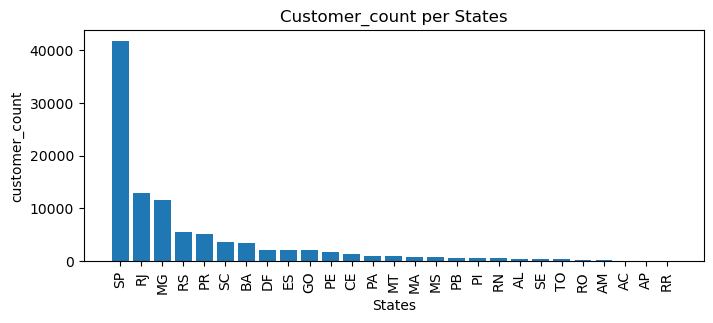

In [48]:
query = """ 
select
customer_state,count(customer_id)
from customers 
group by customer_state
"""
cur.execute(query)
data = cur.fetchall()
data

df=pd.DataFrame(data,columns=["States","Customer_count"])
df=df.sort_values(by ="Customer_count",ascending=False)

plt.figure(figsize = (8,3))
plt.bar(df["States"],df["Customer_count"])
plt.xticks(rotation=90)
plt.xlabel("States")
plt.ylabel("customer_count")
plt.title("Customer_count per States")
plt.show()


# Calculate the moving average of order values for each customer over their order history.

In [3]:
query = """
SELECT
    customer_id,
    order_purchase_timestamp,
    payment,
    AVG(payment) OVER (
        PARTITION BY customer_id
        ORDER BY order_purchase_timestamp
        ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
    ) AS mov_avg
FROM
(
    SELECT
        o.customer_id,
        o.order_purchase_timestamp,
        p.payment_value AS payment
    FROM payments p
    JOIN orders o
        ON p.order_id = o.order_id
) AS a;
"""
cur.execute(query)
data = cur.fetchall()
df=pd.DataFrame(data)
df

,0,1,2,3
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
1,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,67.41,67.410004
2,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,195.42,195.419998
3,0002414f95344307404f0ace7a26f1d5,2017-08-16 13:09:20,179.35,179.350006
4,000379cdec625522490c315e70c7a9fb,2018-04-02 13:42:17,107.01,107.010002
...,...,...,...,...
103881,fffecc9f79fd8c764f843e9951b11341,2018-03-29 16:59:26,0.64,27.120001
103882,fffeda5b6d849fbd39689bb92087f431,2018-05-22 13:36:02,63.13,63.130001
103883,ffff42319e9b2d713724ae527742af25,2018-06-13 16:57:05,214.13,214.130005
103884,ffffa3172527f765de70084a7e53aae8,2017-09-02 11:53:32,45.50,45.500000


#  Calculate the cumulative sales per month for each year.

In [4]:
query = """
select 
year ( orders.order_purchase_timestamp) as year,
month(orders.order_purchase_timestamp) as month ,
round(sum(payments.payment_value),2) 
from orders
join payments 
on orders.order_id=payments.order_id
group by year,month
order by year,month;
"""
cur.execute(query)
data = cur.fetchall()
df=pd.DataFrame(data)
df

,0,1,2
0,2016,9,252.24
1,2016,10,59090.48
2,2016,12,19.62
3,2017,1,138488.04
4,2017,2,291908.01
5,2017,3,449863.60
6,2017,4,417788.03
7,2017,5,592918.82
8,2017,6,511276.38
9,2017,7,592382.92


 # Calculate the year-over-year growth rate of total sales.

In [25]:
query = """ with a as
(select 
year ( orders.order_purchase_timestamp) as years,
round(sum(payments.payment_value),2) as payment 
from orders
join payments 
on orders.order_id=payments.order_id
group by years
order by years)

select years,((payment-lag(payment,1) over(order by years))/lag(payment,1)
over(order by years))*100 from a;
"""
cur.execute(query)
data = cur.fetchall()
df=pd.DataFrame(data,columns=["Years","YOY % Growth"])
df

,Years,YOY % Growth
0,2016,NaN
1,2017,12112.703761
2,2018,20.000924


# Calculate the number of orders per month in 2018.

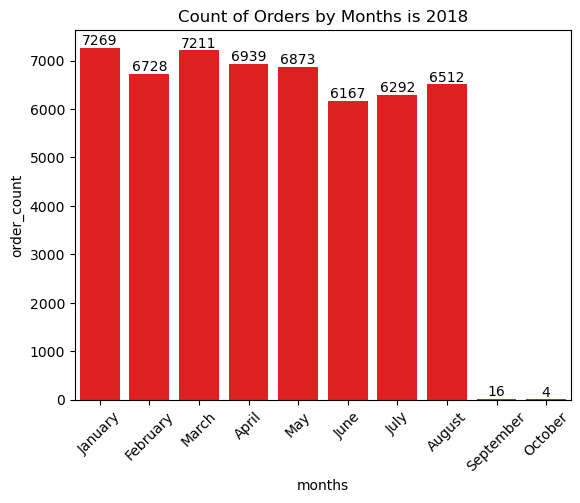

In [34]:
query = """ select monthname(order_purchase_timestamp) months, count(order_id) order_count
from orders where year(order_purchase_timestamp) = 2018
group by months
"""

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data, columns = ["months", "order_count"])
o = ["January", "February","March","April","May","June","July","August","September","October"]

ax = sns.barplot(x = df["months"],y =  df["order_count"], data = df, order = o, color = "red")
plt.xticks(rotation = 45)
ax.bar_label(ax.containers[0])
plt.title("Count of Orders by Months is 2018")

plt.show()




# Identify the top 3 customers who spent the most money in each year.

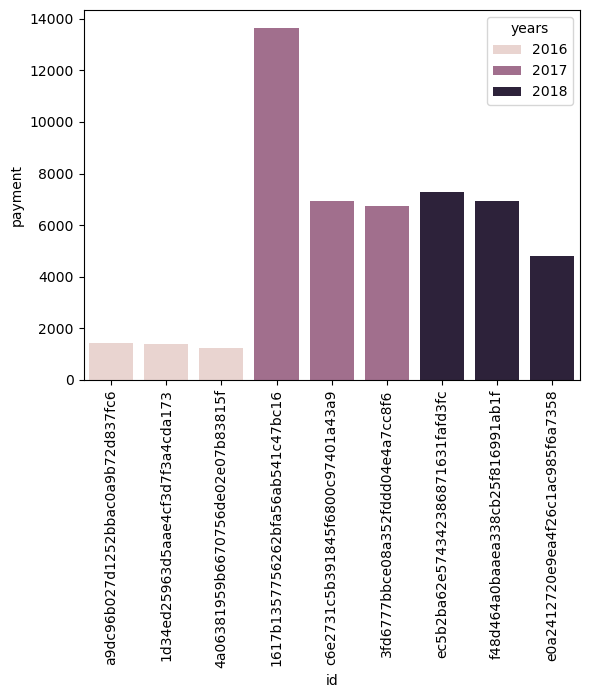

In [35]:
query = """select years, customer_id, payment, d_rank
from
(select year(orders.order_purchase_timestamp) years,
orders.customer_id,
sum(payments.payment_value) payment,
dense_rank() over(partition by year(orders.order_purchase_timestamp)
order by sum(payments.payment_value) desc) d_rank
from orders join payments 
on payments.order_id = orders.order_id
group by year(orders.order_purchase_timestamp),
orders.customer_id) as a
where d_rank <= 3 ;"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns = ["years","id","payment","rank"])
sns.barplot(x = "id", y = "payment", data = df, hue = "years")
plt.xticks(rotation = 90)
plt.show()